Acknowledgments: Aspects of this software implementation were generated with the aid of Generative Artificial Intelligence. All synthetically generated components have been reviewed and verified for structural and functional integrity by the author

In [1]:
# Cell 1: Ensuring HF_TRANSFER is enabled and importing necessary libraries
import os
import torch
import numpy as np
from tqdm import tqdm 
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM
import warnings
import regex 



os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [2]:
# Cell 2: <Mounting/Creating a directory for saving experiment files and defining reusable variables>

# Create a folder for your experiment
SAVE_PATH = 'ArabianGPT_Dialect'
os.makedirs(SAVE_PATH, exist_ok=True)

# Reusable variables
MODEL_ID = "riotu-lab/ArabianGPT-08B-V2"
MODEL_NAME = "ArabianGPT-08B-V2"
DATASET = "MADAR.combined.Arabic.csv"

# Define language codes (add or remove as needed)
LANGUAGE_CODES = ["Aleppo", "Alexandria", "Algiers", "Amman", "Aswan", "Baghdad", "Basra", "Beirut", "Benghazi", "Cairo", "Damascus", "Doha", "Fes", "Jeddah", "Jerusalem", "Khartoum", "Mosul", "MSA", "Muscat", "Rabat", "Riyadh", "Salt", "Sanaa", "Sfax", "Tripoli", "Tunis"]

# Mechanistic Variables
SENTENCE_LIMIT = 100 # The paper uses the first 100 sentences (Sec 4.2).
TARGET_LAYERS = None # None = All layers. Or list: [5, 6, ..., 18]
NUM_LAYERS = 36


# ---------------------------
# Replication toggles (safe defaults)
# ---------------------------
# PCA as in paper: keep 98% variance. If you ever see PCA collapse to ~1-2 dims,
# you can enable a floor on dimensionality (MIN-PCA) to prevent degenerate Gaussians.
PCA_VARIANCE = 0.98           # paper setting
USE_MIN_PCA_DIM = True       # toggle: set True if PCA collapses
PCA_MIN_DIM = 100             # floor used only when USE_MIN_PCA_DIM=True

# Gaussian regularization (improves numerical stability)
REG_COVAR = 1e-6              # recommended; paper doesn't specify exact value

# Figure 4/5 settings
USE_BEST_FOREIGN = True       # paper-style: compare S to best foreign competitor


In [3]:
# Cell 3: Load Data and Create Global Variables for Each Language

# Load the specific file you uploaded
df = pd.read_csv(DATASET)

# Clean column names
df.columns = df.columns.str.strip()

# Load text for each language dynamically
texts_dict = {}
for lang_code in LANGUAGE_CODES:
    if lang_code in df.columns:
        texts_dict[lang_code] = df[lang_code].tolist()
        # Create global variables (texts_ar, texts_cs, etc.) for later cells
        globals()[f'texts_{lang_code}'] = texts_dict[lang_code]

# Print summary
print("✅ Data Loaded:")
for lang_code in LANGUAGE_CODES:
    if lang_code in texts_dict:
        count = len(texts_dict[lang_code])
        print(f"- {lang_code.upper()}: {count} sentences")

✅ Data Loaded:
- ALEPPO: 2000 sentences
- ALEXANDRIA: 2000 sentences
- ALGIERS: 2000 sentences
- AMMAN: 2000 sentences
- ASWAN: 2000 sentences
- BAGHDAD: 2000 sentences
- BASRA: 2000 sentences
- BEIRUT: 2000 sentences
- BENGHAZI: 2000 sentences
- CAIRO: 2000 sentences
- DAMASCUS: 2000 sentences
- DOHA: 2000 sentences
- FES: 2000 sentences
- JEDDAH: 2000 sentences
- JERUSALEM: 2000 sentences
- KHARTOUM: 2000 sentences
- MOSUL: 2000 sentences
- MSA: 2000 sentences
- MUSCAT: 2000 sentences
- RABAT: 2000 sentences
- RIYADH: 2000 sentences
- SALT: 2000 sentences
- SANAA: 2000 sentences
- SFAX: 2000 sentences
- TRIPOLI: 2000 sentences
- TUNIS: 2000 sentences


In [4]:
# Cell 4: Load Model and Tokenizer with optimizations

# 1. Force explicit logging
warnings.filterwarnings("ignore", message="Failed to load image Python extension") # Suppress specific warnings related to image extensions


print(f"--- Starting process for {MODEL_ID} ---")

# 2. Load Tokenizer
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True) #use_fast=True for faster tokenization powered with Rust
tokenizer.pad_token = tokenizer.eos_token # Set pad token to eos token to avoid warnings
print("Tokenizer loaded.")

# 3. Load Model with memory optimizations
print("Loading model (this may take several minutes if downloading)...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, # Use the reusable variable
    torch_dtype=torch.bfloat16, # Use bfloat16 for better memory efficiency on supported hardware
    device_map="auto", # Automatically map model layers to available devices
    low_cpu_mem_usage=True, # Optimize for low CPU memory usage    
    output_hidden_states=True, # Enable output of hidden states for advanced use cases
    use_safetensors=True # Use safetensors format for faster loading and reduced memory usage
)

print(f"Model loaded successfully on: {model.device}")

--- Starting process for riotu-lab/ArabianGPT-08B-V2 ---
Loading tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


Tokenizer loaded.
Loading model (this may take several minutes if downloading)...


The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

Model loaded successfully on: cuda:0


In [5]:
# Cell 5: Function to extract word-aligned vectors using offset mapping and regex for word detection

def get_word_aligned_vectors(text, model, tokenizer, layer_indices=None):
    """
    Extracts word-aligned vectors by averaging sub-token embeddings.
    This matches the methodology described in the paper (Section 4.3).

    Uses offset mapping for more robust word alignment.
    This is more accurate for handling tokenization edge cases.
    
    Args:
        text (str): Input text to process
        model: HuggingFace transformer model
        tokenizer: HuggingFace tokenizer (must be a fast tokenizer)
        layer_indices (list of int, optional): Specific layers to extract.
    
    Returns:
        tuple: (torch.Tensor, list) 
               - Tensor Shape: (num_words, num_layers, hidden_dim)
               - List: The actual words extracted (strings)
    """
    # Tokenize with offset mapping
    encoding = tokenizer(
        text,
        return_tensors="pt", # Returns as Pytorch Tensors
        return_offsets_mapping=True, # Essential for subword averaging
        add_special_tokens=True, # Include special tokens (CLS, SEP) if model uses them
        truncation=False # Used so that input is not cut off by token limit
    )
    
    offsets = encoding.pop("offset_mapping")[0].tolist()  # List of (start, end) tuples for each token
    encoding = {k: v.to(model.device) for k, v in encoding.items()} # Move to model device
    
    # Get hidden states from the model
    with torch.no_grad():
        outputs = model(**encoding, output_hidden_states=True) 

    # Example of **encoding: input_ids=..., attention_mask=...
    # Outputs contains hidden states for all layers
    
    hidden_states = torch.stack(outputs.hidden_states[1:])  # (num_layers, batch_size, seq_len, hidden_dim)
    hidden_states = hidden_states.squeeze(1)  # (num_layers, seq_len, hidden_dim)

    # outputs.hidden_states[0] is the embedding layer, so we skip it
    # .squeeze(1) removes the batch dimension since we have a single input

    if layer_indices is not None: # Just in case we want specific layers
        hidden_states = hidden_states[layer_indices]

    # --- Regex Word Boundary Detection ---
    # \p{L} = Any Unicode Letter (Latin, Cyrillic, Greek, Arabic, etc.)
    # \p{M} = Any Unicode Mark (Accents, Tones)
    # \p{N} = Any Unicode Number (Optional: remove \p{N} if you don't want numbers)
    # This automatically ignores punctuation and spaces.
    word_pattern = regex.compile(r'[\p{L}\p{M}\p{N}]+')
    
    word_vectors = [] # To store final word vectors
    words_list = []   # To store the actual words
    
    # Iterate through regex matches to get word boundaries
    for match in word_pattern.finditer(text):
        word_text = match.group()
        word_start, word_end = match.span() # Start and end char index
        
        word_subtoken_indices = [] # To store sub-token indices for this word
        
        for token_idx, (token_start, token_end) in enumerate(offsets):
            if token_start == 0 and token_end == 0: continue # Skip special tokens with (0,0) offsets
            
            # Check overlap: Does the token overlap with the word in any way?
            # Multilingual tokens often include spaces (e.g. " _word"), so they start BEFORE the word
            if token_start < word_end and token_end > word_start:
                word_subtoken_indices.append(token_idx)
        
        if not word_subtoken_indices: # No sub-tokens found for this word (edge case)
            continue
        
        # Extract embeddings for this word's sub-tokens
        word_subtoken_embeddings = hidden_states[:, word_subtoken_indices, :]  # (num_layers, num_subtokens, hidden_dim)
        
        # Average across sub-tokens
        word_embedding = word_subtoken_embeddings.mean(dim=1)  # (num_layers, hidden_dim) This is the final word embedding
        
        word_vectors.append(word_embedding) # Append to final list
        words_list.append(word_text) # Store the text we found
    
    if not word_vectors: # Handle case where no words were found
        return None, []

    # Stack into final tensor
    word_vectors = torch.stack(word_vectors)  # (num_words, num_layers, hidden_dim)
    
    return word_vectors.cpu(), words_list # Move to CPU for easier handling

In [6]:
# --- TEST SECTION ---

# --- TEST SECTION ---
# Test with a sentence from each language in the dataset

print("Testing sentence extraction for each language:\n")

for lang_code in LANGUAGE_CODES:
    if lang_code not in texts_dict or not texts_dict[lang_code]:
        continue
    
    # Get the first sentence from this language
    text = texts_dict[lang_code][0]
    
    print(f"\n{'='*80}")
    print(f"Language: {lang_code.upper()}")
    print(f"Sentence: {text[:100]}{'...' if len(text) > 100 else ''}")
    print(f"{'='*80}")
    
    vectors, words = get_word_aligned_vectors(text, model, tokenizer)
    
    if vectors is not None:
        print(f"✅ Extracted {len(words)} words")
        print(f"{'WORD':<20} | {'VECTOR SHAPE':<20} | {'FIRST 3 VALUES'}")
        print("-" * 70)
        
        for word, vec in zip(words[:10], vectors[:10]):  # Show first 10 words
            last_layer_vec = vec[-1]
            preview = f"[{last_layer_vec[0].item():.4f}, {last_layer_vec[1].item():.4f}, {last_layer_vec[2].item():.4f}...]"
            print(f"{word:<20} | {str(list(vec.shape)):<20} | {preview}")
        
        if len(words) > 10:
            print(f"... and {len(words) - 10} more words")
    else:
        print("❌ No vectors extracted.")

print(f"\n{'='*80}\n✅ Testing complete.")

Testing sentence extraction for each language:


Language: ALEPPO
Sentence: هو هنيك، قدام معلومات السياح بالضبط.
✅ Extracted 6 words
WORD                 | VECTOR SHAPE         | FIRST 3 VALUES
----------------------------------------------------------------------
هو                   | [36, 1280]           | [1.3516, 1.2031, 0.4414...]
هنيك                 | [36, 1280]           | [1.9844, 1.4062, 1.3594...]
قدام                 | [36, 1280]           | [3.3281, -1.2422, -2.1562...]
معلومات              | [36, 1280]           | [2.2812, 0.5586, 1.0156...]
السياح               | [36, 1280]           | [-2.1094, 0.2539, -1.2344...]
بالضبط               | [36, 1280]           | [0.8906, -0.0359, -2.1250...]

Language: ALEXANDRIA
Sentence: هو هناك، قدام الاستعلامات السياحية على طول.
✅ Extracted 7 words
WORD                 | VECTOR SHAPE         | FIRST 3 VALUES
----------------------------------------------------------------------
هو                   | [36, 1280]           | [1.3516, 1.

In [7]:
# Cell 6: Related to processing the entire sentences of each language/dialect
def process_full_dataset(text_list, model, tokenizer, limit=None):
    """
    Loops through the dataset and creates one giant tensor for the language.
    Args:
    - text_list: List of sentences for the language
    - model: The loaded transformer model
    - tokenizer: The loaded tokenizer
    - limit: Optional limit on number of sentences to process (e.g., 100 as in the replication paper)
    """
    # Apply the limit (e.g., first 100 sentences)
    target_texts = text_list[:limit] if limit else text_list

    all_language_vectors = [] # To store all word vectors for the language
    print(f"Processing {len(target_texts)} sentences...")

    for text in tqdm(target_texts):
        # Skip empty/invalid lines
        if not isinstance(text, str) or not text.strip(): 
            continue
        
        # --- THE FIX ---
        # The function now returns a tuple (vectors, words).
        # We unpack it to get just the vectors.
        result = get_word_aligned_vectors(text, model, tokenizer, TARGET_LAYERS)
        
        if result is None: # Handle case where no words were found
            continue
            
        vectors, words = result # Unpack the tuple
        
        if vectors is not None:
            all_language_vectors.append(vectors)

    # Concatenate all words from all sentences into one list
    # Result Shape: (Total_Words_In_Language, Num_Layers, Hidden_Dim)
    if not all_language_vectors: return None
    return torch.cat(all_language_vectors, dim=0) # Concatenate along the word dimension

In [8]:
# Cell 7: Execution and saving

# --- EXECUTION ---

# Process all languages dynamically using loops
vectors_dict = {}
for lang_code in LANGUAGE_CODES:
    if lang_code in texts_dict:
        print(f"--- Extracting {lang_code.upper()} ---")
        vectors = process_full_dataset(texts_dict[lang_code], model, tokenizer, limit=SENTENCE_LIMIT)
        vectors_dict[lang_code] = vectors
        # Create global variables (vectors_ar, vectors_cs, etc.) for compatibility with later cells
        globals()[f'vectors_{lang_code}'] = vectors

# --- SAVING ---
# Save as .pt (PyTorch tensors) - faster and smaller than .npy for this shape

for lang_code in LANGUAGE_CODES:
    if vectors_dict[lang_code] is not None:
        torch.save(vectors_dict[lang_code], f"{SAVE_PATH}/vecs_{lang_code}.pt")


print(f"Extraction Complete. Files saved to {SAVE_PATH} folder.")

--- Extracting ALEPPO ---
Processing 100 sentences...


100%|██████████| 100/100 [00:01<00:00, 57.12it/s]


--- Extracting ALEXANDRIA ---
Processing 100 sentences...


100%|██████████| 100/100 [00:01<00:00, 58.74it/s]


--- Extracting ALGIERS ---
Processing 100 sentences...


...

--- Extracting TRIPOLI ---
Processing 100 sentences...


100%|██████████| 100/100 [00:01<00:00, 59.40it/s]


--- Extracting TUNIS ---
Processing 100 sentences...


100%|██████████| 100/100 [00:01<00:00, 58.97it/s]


Extraction Complete. Files saved to ArabianGPT_Dialect folder.


In [9]:
# Cell 8: Build Language Spaces (Paper Section 4.3)
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

def fit_pca_with_optional_floor(X, var=0.98, use_min_dim=False, min_dim=16, random_state=0):
    """Fit PCA keeping `var` explained variance; optionally refit with a minimum number of dims."""
    pca = PCA(n_components=var, svd_solver="full", random_state=random_state)
    pca.fit(X)
    if use_min_dim and isinstance(pca.n_components_, (int, np.integer)) and pca.n_components_ < min_dim:
        pca = PCA(n_components=min_dim, svd_solver="full", random_state=random_state)
        pca.fit(X)
    return pca

def build_language_space(layer_idx, vectors_dict,
                        pca_variance=PCA_VARIANCE,
                        use_min_pca_dim=USE_MIN_PCA_DIM,
                        pca_min_dim=PCA_MIN_DIM,
                        reg_covar=REG_COVAR,
                        seed=0):
    """
    Builds a shared PCA and one Gaussian (1-component GMM) per language at the specified layer.
    - PCA is fit on pooled token vectors across languages, keeping `pca_variance` explained variance.
    - Optional MIN-PCA floor prevents degenerate low-dimensional PCA in pathological layers.
    - Gaussians are fitted in PCA space with full covariance.
    """
    layer_data = {}
    all_data_list = []

    # 1) Slice per-language layer vectors and collect universe matrix (float64 for stability)
    for lang, tensor in vectors_dict.items():
        if tensor is None:
            continue
        flat_vecs = tensor[:, layer_idx, :].double().numpy()  # (N_tokens, hidden_dim)
        layer_data[lang] = flat_vecs
        all_data_list.append(flat_vecs)

    universe_matrix = np.vstack(all_data_list)

    # 2) Fit shared PCA (optionally with min-dim floor)
    pca = fit_pca_with_optional_floor(
        universe_matrix,
        var=pca_variance,
        use_min_dim=use_min_pca_dim,
        min_dim=pca_min_dim,
        random_state=seed
    )

    # 3) Fit one Gaussian per language in PCA space
    gmm_models = {}
    for lang, raw_vecs in layer_data.items():
        Z = pca.transform(raw_vecs)

        gmm = GaussianMixture(
            n_components=1, # One Gaussian per language
            covariance_type="full", # Full covariance for flexibility; paper doesn't specify exact type
            reg_covar=reg_covar, # Regularization for numerical stability; paper doesn't specify exact value
            random_state=seed, # Random state for reproducibility; paper doesn't specify exact value
            max_iter=300 # Maximum iterations for convergence; paper doesn't specify exact value
        )
        gmm.fit(Z)
        gmm_models[lang] = gmm

    return pca, gmm_models


In [10]:
# Cell 9: Run Full Layer-Wise Analysis (Numerically Stable Version)
from scipy.special import softmax
from tqdm import tqdm

def get_dominance_scores(source_vecs, all_gmms, pca):
    """
    Calculates P(Target | Source) using Stable Softmax.
    Prevents Overflow/NaN errors by staying in Log-Space.
    Args:
        source_vecs (np.ndarray): Source language vectors (N_words, Hidden_Dim)
        all_gmms (dict): Dictionary of GMM models per layer
        pca: Shared PCA object
    Returns:
        dict: Mapping of language to dominance score
    """
    # Project Source data into Shared Space
    projected_source = pca.transform(source_vecs)

    # 1. Collect LOG-Likelihoods (Do not use exp yet!)
    log_likelihoods_list = []
    lang_order = []

    for lang, gmm in all_gmms.items(): # Through each language
        log_prob = gmm.score_samples(projected_source) # Log-Likelihoods for each word
        log_likelihoods_list.append(log_prob) # Collect log-likelihoods
        lang_order.append(lang) # Keep track of language order

    # Stack: Shape (N_words, N_Languages)
    # This matrix contains values like -500.0, -200.0, etc.
    log_likelihoods_matrix = np.stack(log_likelihoods_list, axis=1) # Shape: (N_words, N_Languages)

    # 2. Apply Stable Softmax
    # Formula: exp(x - max(x)) / sum(exp(x - max(x)))
    # scipy.special.softmax handles this automatically on axis 1
    posteriors = softmax(log_likelihoods_matrix, axis=1)

    # 3. Average across all words
    mean_posteriors = np.mean(posteriors, axis=0)

    # Map back to language names
    return dict(zip(lang_order, mean_posteriors))


In [11]:
# Cell 10: Figure 1: NMI across layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.auto import tqdm

from sklearn.metrics import normalized_mutual_info_score
from scipy.special import softmax

# --- Build data dictionary ---
data_dict = {
    lang_code: globals()[f'vectors_{lang_code}'].cpu()
    for lang_code in LANGUAGE_CODES
    if f'vectors_{lang_code}' in globals() and globals()[f'vectors_{lang_code}'] is not None
}

print(f"Data Dictionary Built with Keys: {list(data_dict.keys())}")

# Define language subsets
train_iso = LANGUAGE_CODES
ood_iso   = LANGUAGE_CODES

# --- CACHING: PCA + GMM per layer ---
LANGSPACE_CACHE = {}

def get_language_space_cached(layer_idx):
    """Returns (pca, gmms) for layer_idx, computing it once and caching."""
    if layer_idx not in LANGSPACE_CACHE:
        LANGSPACE_CACHE[layer_idx] = build_language_space(layer_idx, data_dict)
    return LANGSPACE_CACHE[layer_idx]

def predict_labels_for_layer(layer_idx):
    """Predict language labels for all word vectors at a given layer."""
    pca, gmms = get_language_space_cached(layer_idx)

    X_list, y_list = [], []
    for lang_iso, tensor in data_dict.items():
        X = tensor[:, layer_idx, :].double().numpy()
        y = np.array([lang_iso] * X.shape[0])
        X_list.append(X)
        y_list.append(y)

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    Z = pca.transform(X)

    lang_isos = list(gmms.keys())
    logL = []
    for iso in lang_isos:
        logL.append(gmms[iso].score_samples(Z))
    logL = np.stack(logL, axis=1)  # (N, n_lang)

    post = softmax(logL, axis=1)
    pred_idx = post.argmax(axis=1)
    yhat = np.array([lang_isos[i] for i in pred_idx])

    return y, yhat

# --- Figure 1: NMI across layers ---
nmi_all = []

t0 = time.time()
for layer_idx in tqdm(range(NUM_LAYERS), desc="Figure 1: NMI across layers"):
    y, yhat = predict_labels_for_layer(layer_idx)

    nmi_all.append(normalized_mutual_info_score(y, yhat))


Data Dictionary Built with Keys: ['Aleppo', 'Alexandria', 'Algiers', 'Amman', 'Aswan', 'Baghdad', 'Basra', 'Beirut', 'Benghazi', 'Cairo', 'Damascus', 'Doha', 'Fes', 'Jeddah', 'Jerusalem', 'Khartoum', 'Mosul', 'MSA', 'Muscat', 'Rabat', 'Riyadh', 'Salt', 'Sanaa', 'Sfax', 'Tripoli', 'Tunis']


Figure 1: NMI across layers:   0%|          | 0/36 [00:00<?, ?it/s]


=== All Languages (ArabianGPT-08B-V2) DataFrame ===
 Layer      NMI
     1 0.695217
     2 0.702211
     3 0.706677
     4 0.716812
     5 0.731900
     6 0.736743
     7 0.737321
     8 0.738146
     9 0.738665
    10 0.738680
    11 0.738182
    12 0.738160
    13 0.738213
    14 0.738747
    15 0.740952
    16 0.740983
    17 0.619815
    18 0.111483
    19 0.116593
    20 0.122089
    21 0.124229
    22 0.128692
    23 0.140020
    24 0.138344
    25 0.135112
    26 0.153715
    27 0.174732
    28 0.164278
    29 0.174297
    30 0.191616
    31 0.402028
    32 0.741407
    33 0.741407
    34 0.741407
    35 0.741826
    36 0.741302

Saved layer-wise NMI data to: ArabianGPT_Dialect/arabiangpt_08b_v2_layerwise_nmi_all_languages.csv


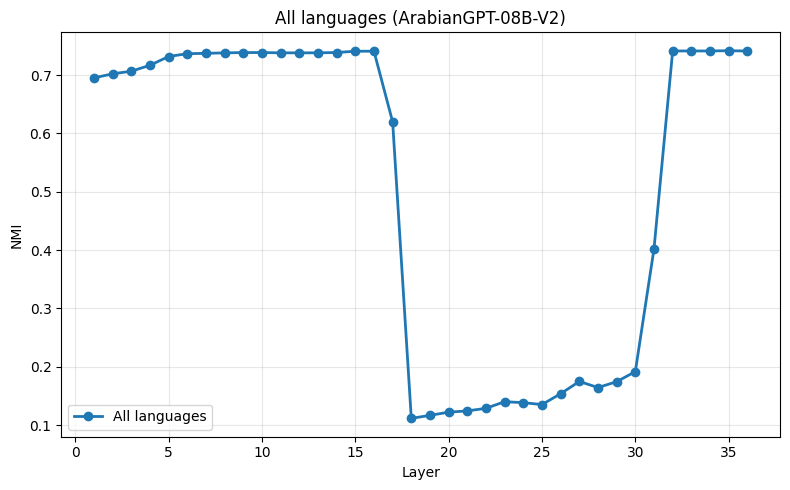

In [12]:
# Cell 11: Layer-wise NMI Metric Analysis for All Languages
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Define layers (1-indexed for clear plotting representation)
layers = list(range(1, NUM_LAYERS + 1))

# Create a clean DataFrame holding the metrics
df_all = pd.DataFrame({
    "Layer": layers,
    "NMI": nmi_all
})

# Display the data table once
print(f"\n=== All Languages ({MODEL_NAME}) DataFrame ===")
print(df_all.to_string(index=False))

# --- SAVE DATA ---
# Construct descriptive path and save metrics to CSV
output_nmi_path = Path(SAVE_PATH) / f"{MODEL_NAME.lower().replace('-', '_')}_layerwise_nmi_all_languages.csv"
output_nmi_path.parent.mkdir(parents=True, exist_ok=True)
df_all.to_csv(output_nmi_path, index=False)
print(f"\nSaved layer-wise NMI data to: {output_nmi_path}")

# --- PLOT ONLY THE ALL LANGUAGES GRAPH ---
plt.figure(figsize=(8, 5))

plt.plot(
    layers,
    nmi_all,
    marker='o',
    linewidth=2,
    label='All languages'
)

plt.title(f"All languages ({MODEL_NAME})")
plt.xlabel("Layer")
plt.ylabel("NMI")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Saved confusion matrix CSV to: ArabianGPT_Dialect/arabiangpt_08b_v2_mid_layers_confusion_matrix.csv

Top confusions for each dialect:
  Aleppo most confused with Beirut: 1.07%
  Alexandria most confused with Aleppo: 4.21%
  Algiers most confused with Sfax: 3.24%
  Amman most confused with Aleppo: 9.79%
  Aswan most confused with Aleppo: 3.68%
  Baghdad most confused with Basra: 13.37%
  Basra most confused with Aleppo: 5.62%
  Beirut most confused with Aleppo: 9.20%
  Benghazi most confused with Aleppo: 4.15%
  Cairo most confused with Doha: 3.65%
  Damascus most confused with Aleppo: 16.27%
  Doha most confused with Aleppo: 5.67%
  Fes most confused with Aleppo: 4.29%
  Jeddah most confused with Aleppo: 3.97%
  Jerusalem most confused with Aleppo: 11.38%
  Khartoum most confused with Aleppo: 5.56%
  Mosul most confused with Aleppo: 4.15%
  MSA most confused with Baghdad: 3.62%
  Muscat most confused with Aleppo: 5.03%
  Rabat most confused with Fes: 5.84%
  Riyadh most confused with A

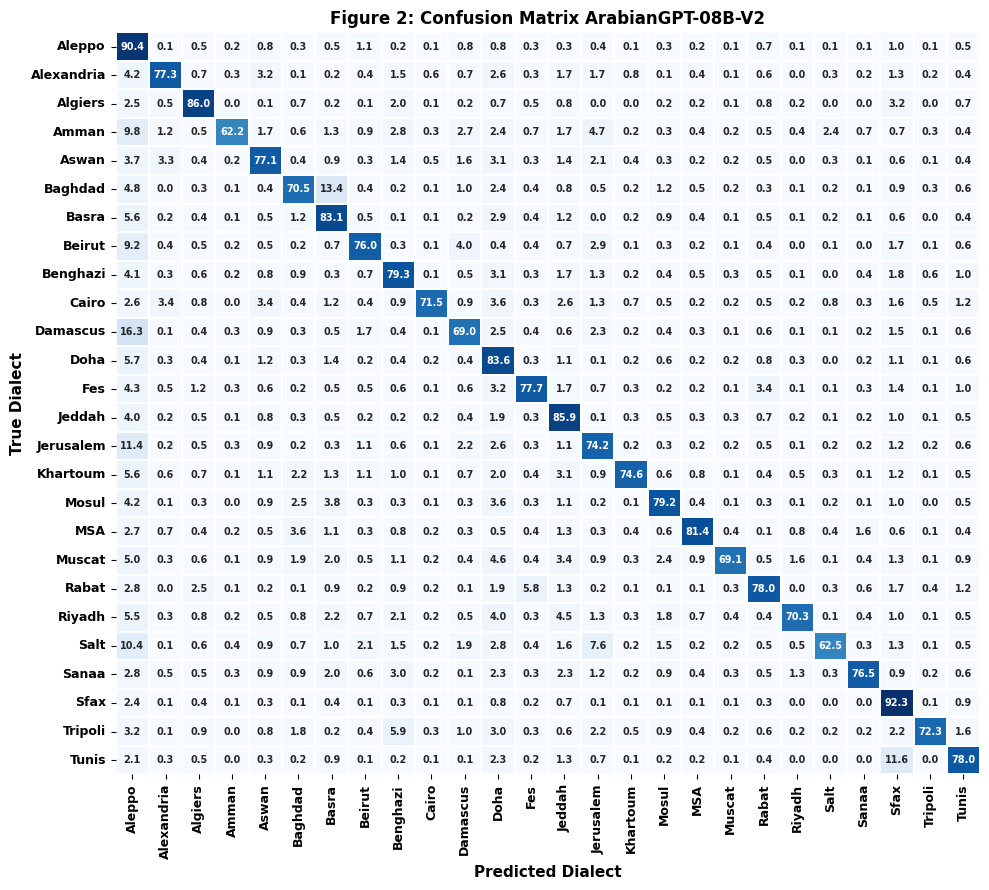

In [13]:
# Cell 12: Figure 2: Confusion Matrix & Dialect Confusion Analysis
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Define ISO language order
iso_order = LANGUAGE_CODES

mid_layers = list(range(4, 18))

# 1. RUN ANALYSIS (Runs exactly once)
ys, yhats = [], []
for layer_idx in mid_layers:
    y_layer, yhat_layer = predict_labels_for_layer(layer_idx)
    ys.append(y_layer)
    yhats.append(yhat_layer)

y = np.concatenate(ys)
yhat = np.concatenate(yhats)

# Compute normalized confusion matrix percentage
cm = confusion_matrix(y, yhat, labels=iso_order, normalize="true") * 100.0

# 2. SAVE CLEAN DATA TABLE / CSV
cm_df = pd.DataFrame(cm, index=iso_order, columns=iso_order)

# Construct descriptive save path using the SAVE_PATH constant
output_csv_path = Path(SAVE_PATH) / f"{MODEL_NAME.lower().replace('-', '_')}_mid_layers_confusion_matrix.csv"
output_csv_path.parent.mkdir(parents=True, exist_ok=True)  # Ensure directory exists
cm_df.to_csv(output_csv_path)
print(f"Saved confusion matrix CSV to: {output_csv_path}")

# 3. PRINT TOP CONFUSIONS PER DIALECT
print("\nTop confusions for each dialect:")
for dialect in iso_order:
    row = cm_df.loc[dialect].drop(dialect)  # Remove diagonal self-prediction
    top_confused = row.idxmax()
    value = row.max()
    print(f"  {dialect} most confused with {top_confused}: {value:.2f}%")

# 4. PLOT COMPRESSED HEATMAP (Using calculated CM matrix data)
fig, ax = plt.subplots(figsize=(10, 9))

sns.heatmap(
    cm,
    ax=ax,
    xticklabels=iso_order,
    yticklabels=iso_order,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7, "weight": "bold"},       # Optimized font for 26x26 grid
    cmap="Blues",                                   
    cbar=False,                                    
    linewidths=0.3,
    linecolor="white",
)

# 90-degree rotation allows horizontal compression without label collision
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=9, weight="bold")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, weight="bold")

ax.set_xlabel("Predicted Dialect", fontsize=11, weight="bold")
ax.set_ylabel("True Dialect", fontsize=11, weight="bold")
ax.set_title(f"Figure 2: Confusion Matrix {MODEL_NAME}", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()

Computing dominance scores for 36 layers...


Figure 3: Dominance scores:   0%|          | 0/36 [00:00<?, ?it/s]

Saved dominance heatmap values to: ArabianGPT_Dialect/arabiangpt_08b_v2_language_dominance_scores.csv


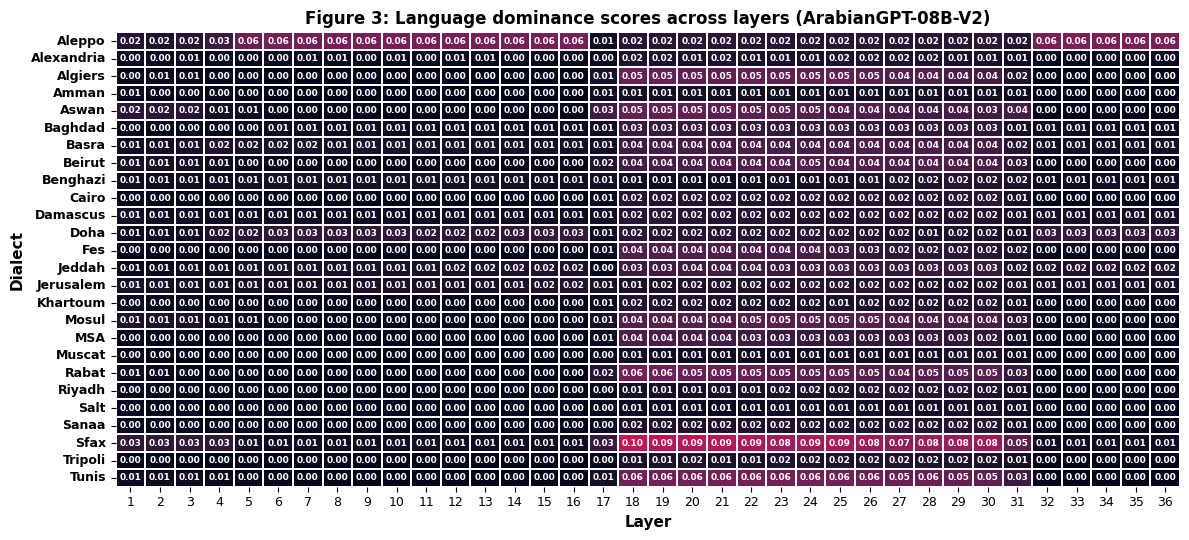

In [14]:
# Cell 13: Figure 3: Language dominance scores across layers
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Define ISO language order
iso_order = LANGUAGE_CODES

# Compute dominance scores for Figure 3 (Runs exactly once)
dominance_history = []

print(f"Computing dominance scores for {NUM_LAYERS} layers...")
for layer_idx in tqdm(range(NUM_LAYERS), desc="Figure 3: Dominance scores"):
    try:
        pca, gmm_models = get_language_space_cached(layer_idx)
        layer_results = {"layer": layer_idx}

        for source_lang in iso_order:
            source_data = data_dict[source_lang][:, layer_idx, :].double().numpy()
            scores = get_dominance_scores(source_data, gmm_models, pca)

            for target_lang, score in scores.items():
                key = f"{target_lang}_over_{source_lang}"
                layer_results[key] = score

        dominance_history.append(layer_results)

    except Exception as e:
        print(f"Skipping Layer {layer_idx} due to error: {e}")

df_results = pd.DataFrame(dominance_history)

# Ensure df_results is ordered by layer
df_sorted = df_results.sort_values("layer").reset_index(drop=True)

# Paper Eq(3): D_T^l = mean_{S != T} P(T | S)
D = pd.DataFrame({"layer": df_sorted["layer"]})
for tgt_lang in iso_order:
    cols = [f"{tgt_lang}_over_{src_lang}" for src_lang in iso_order if src_lang != tgt_lang]
    D[tgt_lang] = df_sorted[cols].mean(axis=1)

# Convert to ISO row order for plotting and export structured table
heat = np.zeros((len(iso_order), NUM_LAYERS), dtype=float)
for r, iso in enumerate(iso_order):
    heat[r, :] = D[iso].values

# --- SAVE DATA ---
df_dom_matrix = pd.DataFrame(heat, index=iso_order, columns=list(range(1, NUM_LAYERS + 1)))
output_dom_path = Path(SAVE_PATH) / f"{MODEL_NAME.lower().replace('-', '_')}_language_dominance_scores.csv"
output_dom_path.parent.mkdir(parents=True, exist_ok=True)
df_dom_matrix.to_csv(output_dom_path)
print(f"Saved dominance heatmap values to: {output_dom_path}")

# --- INTEGRATED HEAVILY COMPRESSED PLOTTING ---
# Flattened canvas across 26 dialects
fig, ax = plt.subplots(figsize=(12, 5.5))
layer_labels = list(range(1, NUM_LAYERS + 1))

sns.heatmap(
    heat,
    ax=ax,
    xticklabels=layer_labels,
    yticklabels=iso_order,
    vmin=0.0,
    vmax=0.20,
    cbar=False,                                    
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6.5, "weight": "bold"},     # Calibrated to fit high matrix density
    linewidths=0.3,
    linecolor="white",
)

# Set axis constraints with clean horizontal layouts
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, weight="bold")
ax.set_xticklabels(layer_labels, fontsize=9, rotation=0)

ax.set_xlabel("Layer", fontsize=11, weight="bold")
ax.set_ylabel("Dialect", fontsize=11, weight="bold")
ax.set_title(f"Figure 3: Language dominance scores across layers ({MODEL_NAME})", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()

In [15]:
# Cell 14: Figure 4/5: Dominance score line plots 
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.special import logsumexp


def posteriors_for_layer(layer_idx):
    """Return (post, y_true, lang_isos) for all tokens in a layer, using cached PCA+Gaussians."""
    pca, gmms = get_language_space_cached(layer_idx)

    X_list, y_list = [], []
    for lang_iso, tensor in data_dict.items():
        X = tensor[:, layer_idx, :].double().numpy()
        y = np.array([lang_iso] * X.shape[0])
        X_list.append(X); y_list.append(y)

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    Z = pca.transform(X)

    lang_isos = list(gmms.keys())
    logL = np.stack([gmms[iso].score_samples(Z) for iso in lang_isos], axis=1)  # (N, K)

    # stable log-softmax
    log_post = logL - logsumexp(logL, axis=1, keepdims=True)
    post = np.exp(log_post)
    return post, y, lang_isos
    

Figure 4 (pairwise): dominated fraction per layer:   0%|          | 0/36 [00:00<?, ?it/s]


=== Dominated Fraction (ArabianGPT-08B-V2) DataFrame ===


,Layer,Lambda_lt_1_pct,Lambda_gt_1_pct
0,1,10.494415,89.505585
1,2,11.067467,88.932533
2,3,11.397250,88.602750
3,4,12.043386,87.956614
4,5,15.490994,84.509006
5,6,16.590096,83.409904
6,7,16.789980,83.210020
7,8,16.835432,83.164568
8,9,16.827168,83.172832
9,10,16.819420,83.180580


Saved fraction statistics to: ArabianGPT_Dialect/arabiangpt_08b_v2_pairwise_dominated_fractions.csv


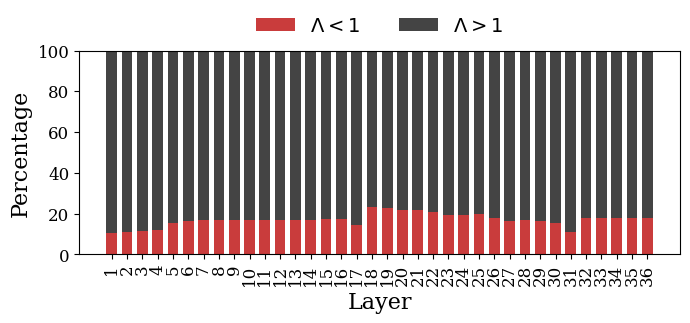

In [16]:
# Cell 15: Figure 4: Dominated fraction per layer (pairwise Λ)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def dominated_fractions_per_layer_pairwise():
    """Computes the fraction of pairwise comparisons where Λ < 1 vs Λ > 1 for each layer.
    
    This is a more granular version of the analysis in Figure 4, looking at all pairwise comparisons
    rather than just the best competitor. It provides a fuller picture of how often the true language 
    is more likely than each competitor across the board.
    """
    frac_lt1 = np.zeros(NUM_LAYERS, dtype=float)
    frac_gt1 = np.zeros(NUM_LAYERS, dtype=float)

    for layer_idx in tqdm(range(NUM_LAYERS), desc="Figure 4 (pairwise): dominated fraction per layer"):
        post, y, lang_isos = posteriors_for_layer(layer_idx)
        idx = {iso: i for i, iso in enumerate(lang_isos)}
        y_idx = np.array([idx[iso] for iso in y], dtype=int)

        N, K = post.shape
        post_self = post[np.arange(N), y_idx]  # (N,)

        # --- Pairwise Λ computation ---
        # Λ_{n,c} = p_true[n] / p_c[n] for all competitors c ≠ true
        lam = post_self[:, None] / (post + 1e-12)  # shape (N, K)

        # mask out the true class for each token
        mask = np.ones((N, K), dtype=bool)
        mask[np.arange(N), y_idx] = False

        lam_pairs = lam[mask]                 # shape (N * (K-1),)
        lam_pairs = lam_pairs[np.isfinite(lam_pairs)]
        if lam_pairs.size == 0:
            continue

        # --- Flat pooling over all pairwise Λ in this layer ---
        frac_lt1[layer_idx] = np.mean(lam_pairs < 1.0)
        frac_gt1[layer_idx] = 1.0 - frac_lt1[layer_idx]

    return frac_lt1, frac_gt1


# 1. RUN ANALYSIS (Runs exactly once)
frac_lt1, frac_gt1 = dominated_fractions_per_layer_pairwise()

# Convert fractions to metrics percentages
x = np.arange(1, NUM_LAYERS + 1)
lt1_pct = 100.0 * frac_lt1
gt1_pct = 100.0 * frac_gt1

# 2. CREATE DATAFRAME & PREVIEW
df_dominated = pd.DataFrame({
    "Layer": x,
    "Lambda_lt_1_pct": lt1_pct,
    "Lambda_gt_1_pct": gt1_pct
})

print(f"\n=== Dominated Fraction ({MODEL_NAME}) DataFrame ===")
display(df_dominated)

# 3. SAVE TO DESCRIPTIVE CSV PATH
output_csv_path = Path(SAVE_PATH) / f"{MODEL_NAME.lower().replace('-', '_')}_pairwise_dominated_fractions.csv"
output_csv_path.parent.mkdir(parents=True, exist_ok=True)
df_dominated.to_csv(output_csv_path, index=False)
print(f"Saved fraction statistics to: {output_csv_path}")

# 4. PLOTTING (Clean stacked bar representation)
plt.figure(figsize=(7, 3.5))
plt.bar(x, lt1_pct, color="#c93c3c", label=r"$\Lambda < 1$", width=0.7)
plt.bar(x, gt1_pct, bottom=lt1_pct, color="#444444", label=r"$\Lambda > 1$", width=0.7)

plt.xlabel("Layer", fontsize=16, family='serif')
plt.ylabel("Percentage", fontsize=16, family='serif')
plt.ylim(0, 100)
plt.xticks(x, fontsize=12, family='serif', rotation=90)
plt.yticks(np.arange(0, 101, 20), fontsize=12, family='serif')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25),
           ncol=2, frameon=False, fontsize=12, prop={'family': 'serif', 'size': 14})
plt.tight_layout()
plt.show()

Figure 5 (pairwise): collecting dominated Λ over all layers:   0%|          | 0/36 [00:00<?, ?it/s]


Saved raw values to: ArabianGPT_Dialect/arabiangpt_08b_v2_dominated_lambda_raw_values.csv
Saved histogram values to: ArabianGPT_Dialect/arabiangpt_08b_v2_dominated_lambda_histogram.csv

=== Histogram Data Sample (ArabianGPT-08B-V2) ===


,Bin_Center,Frequency
0,0.005,1868248
1,0.015,59831
2,0.025,37547
3,0.035,27033
4,0.045,23073
5,0.055,19125
6,0.065,16303
7,0.075,13819
8,0.085,12294
9,0.095,11805


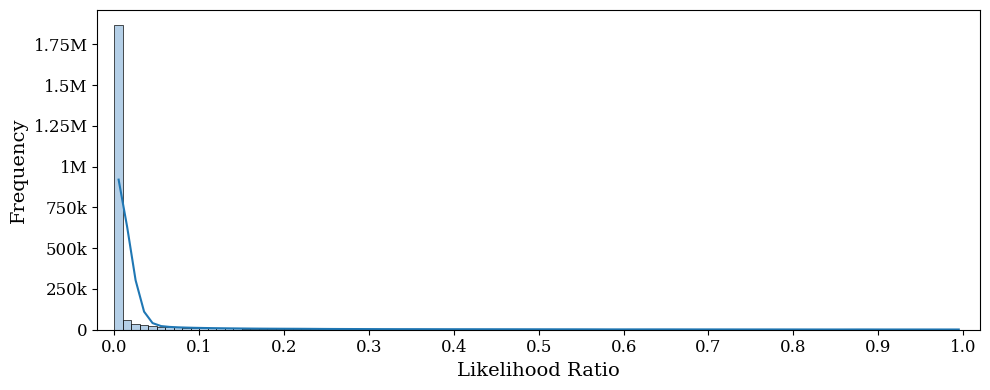

In [17]:
# Cell 16: Figure 5: Distribution of dominated Λ values (pairwise)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.ndimage import gaussian_filter1d
from matplotlib.ticker import EngFormatter

def collect_dominated_lambdas_all_layers_pairwise():
    """Collects all pairwise Λ values that are dominated (0 < Λ < 1) across all layers.
    
    Returns:
        np.ndarray: Array of all dominated Λ values across layers.
    """
    ratios = []

    for layer_idx in tqdm(range(NUM_LAYERS), desc="Figure 5 (pairwise): collecting dominated Λ over all layers"):
        post, y, lang_isos = posteriors_for_layer(layer_idx)
        idx = {iso: i for i, iso in enumerate(lang_isos)}
        y_idx = np.array([idx[iso] for iso in y], dtype=int)

        N, K = post.shape
        post_self = post[np.arange(N), y_idx]  # (N,)

        # --- Pairwise Λ ---
        lam = post_self[:, None] / (post + 1e-12)  # (N, K)

        # mask out the true class
        mask = np.ones((N, K), dtype=bool)
        mask[np.arange(N), y_idx] = False

        lam_pairs = lam[mask]                     # (N * (K-1),)
        lam_pairs = lam_pairs[np.isfinite(lam_pairs)]

        # dominated only
        lam_dom = lam_pairs[(lam_pairs > 0) & (lam_pairs < 1)]
        if lam_dom.size > 0:
            ratios.append(lam_dom)

    return np.concatenate(ratios) if ratios else np.array([])


# 1. RUN ANALYSIS (Runs exactly once)
ratios = collect_dominated_lambdas_all_layers_pairwise()

# Initialize path definitions
save_dir = Path(SAVE_PATH)
save_dir.mkdir(parents=True, exist_ok=True)
model_prefix = MODEL_NAME.lower().replace('-', '_')

# 2. FILE SAVING & PREVIEWS
if ratios.size > 0:
    # Save Raw Array Distribution Data
    df_ratios = pd.DataFrame({"Dominated_Lambda": ratios})
    raw_csv_path = save_dir / f"{model_prefix}_dominated_lambda_raw_values.csv"
    df_ratios.to_csv(raw_csv_path, index=False)
    print(f"\nSaved raw values to: {raw_csv_path}")

    # Compute and Save Plot Bins / Histogram Data
    n_bins = 100
    counts, bin_edges = np.histogram(ratios, bins=n_bins, range=(0, 1))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    df_hist = pd.DataFrame({
        "Bin_Center": bin_centers,
        "Frequency": counts
    })
    hist_csv_path = save_dir / f"{model_prefix}_dominated_lambda_histogram.csv"
    df_hist.to_csv(hist_csv_path, index=False)
    print(f"Saved histogram values to: {hist_csv_path}")

    # Display clean table sample summary
    print(f"\n=== Histogram Data Sample ({MODEL_NAME}) ===")
    display(df_hist.head(10))
else:
    print("\nNo dominated tokens found ($\Lambda < 1$). Skipping exports.")

# 3. PLOTTING (Consistent with requested style profiles)
plt.figure(figsize=(10, 4))
if ratios.size == 0:
    plt.text(0.5, 0.5, "No dominated tokens found ($\Lambda < 1$)", ha="center", va="center")
    plt.axis("off")
else:
    plt.bar(bin_centers, counts, width=(1/n_bins),
            color="#a2c4e1", edgecolor="black", linewidth=0.6, alpha=0.8)

    smoothed_counts = gaussian_filter1d(counts, sigma=1.5)
    plt.plot(bin_centers, smoothed_counts, color="#1f77b4", linewidth=1.5)

    plt.xlabel("Likelihood Ratio", fontsize=14, family='serif')
    plt.ylabel("Frequency", fontsize=14, family='serif')
    plt.xticks(np.arange(0, 1.1, 0.1), fontsize=12, family='serif')
    plt.yticks(fontsize=12, family='serif')
    plt.xlim(-0.02, 1.02)
    plt.gca().yaxis.set_major_formatter(EngFormatter(sep=""))

plt.tight_layout()
plt.show()